# Analisis Clustering Performa Siswa Menggunakan K-Means


## Setup dan Impor Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

## 1. Baca dan Eksplorasi Dataset

In [2]:
df = pd.read_csv('student_dataset_10000_rows.csv')
display(df.head())
df.info()
display(df.describe())

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


### Cek Missing Values dan Outliers

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64


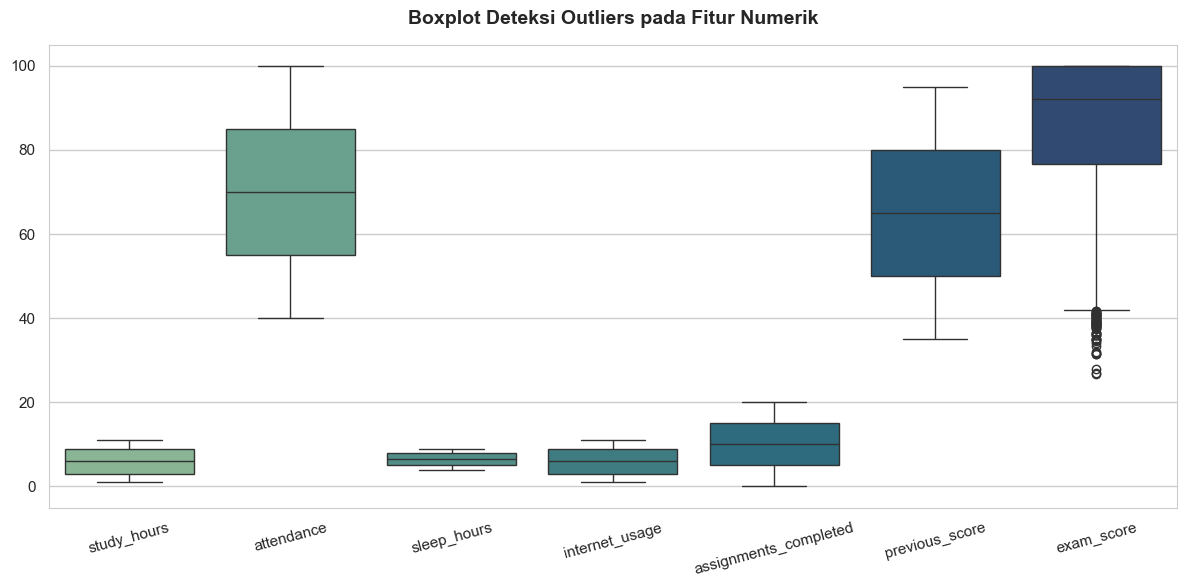

In [3]:
print(df.isnull().sum())

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette='crest')
plt.title('Boxplot Deteksi Outliers pada Fitur Numerik', fontsize=14, pad=15, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('boxplot_outliers.png', dpi=300)
plt.show()

## 2. Pilih Fitur untuk Clustering

In [4]:
features_to_use = ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score']
X = df[features_to_use]

print("Fitur terpilih untuk clustering:", features_to_use)
print("Dimensi data input:", X.shape)

Fitur terpilih untuk clustering: ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score', 'exam_score']
Dimensi data input: (10000, 7)


## 3. Preprocessing (Normalisasi)

In [5]:
# Normalisasi menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_to_use)

display(X_scaled_df.head())

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
0,0.319400,-0.788197,0.878446,0.298725,0.001922,-0.166322,0.882994
1,-0.628937,-0.050217,-0.876691,-0.975970,-0.329541,-0.509138,0.882994
2,1.583850,-0.561126,0.293400,-0.019949,0.001922,-1.137632,0.882994
3,0.635513,1.652815,1.463492,0.617398,-0.992469,-0.566273,0.230169
4,-0.312825,-1.015268,0.878446,-0.019949,-0.329541,-1.423311,-0.523602


## 4. Menentukan Jumlah Klaster Optimal (K)

Menghitung Inertia dan Silhouette Score untuk K=2 sampai 10...
K=2 | Inertia=56984.79 | Silhouette Score=0.1797
K=3 | Inertia=51831.62 | Silhouette Score=0.1362
K=4 | Inertia=48125.76 | Silhouette Score=0.1338
K=5 | Inertia=45438.56 | Silhouette Score=0.1287
K=6 | Inertia=43016.74 | Silhouette Score=0.1207
K=7 | Inertia=41053.92 | Silhouette Score=0.1221
K=8 | Inertia=39259.21 | Silhouette Score=0.1233
K=9 | Inertia=37914.75 | Silhouette Score=0.1237
K=10 | Inertia=36448.37 | Silhouette Score=0.1261


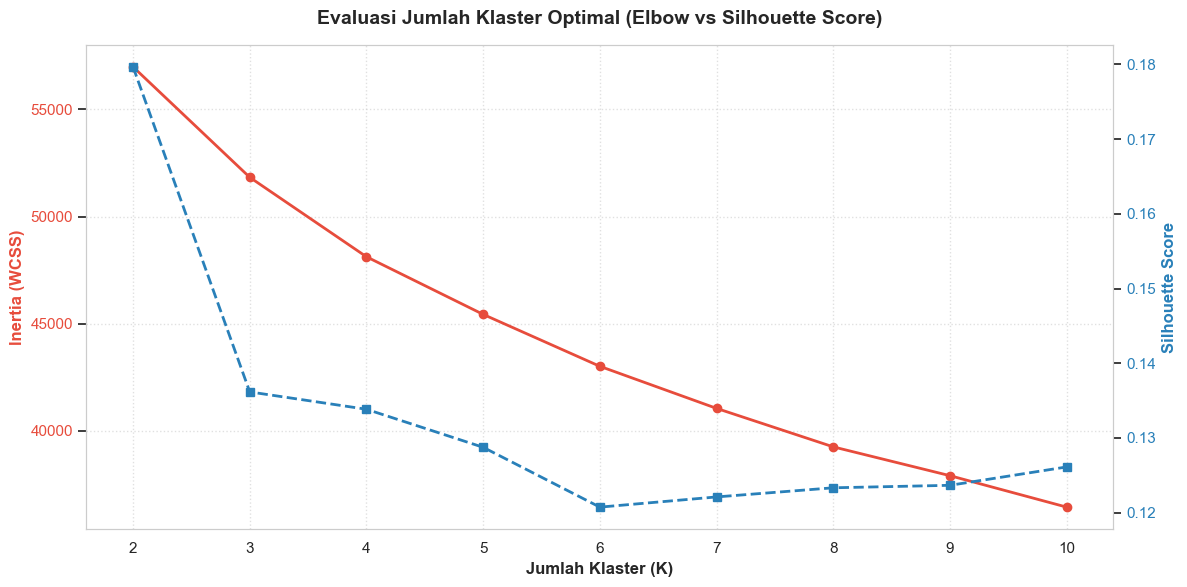


Rekomendasi K terbaik dari Silhouette Score: 2 (Score: 0.1797)


In [6]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

print("Menghitung Inertia dan Silhouette Score untuk K=2 sampai 10...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia={kmeans.inertia_:.2f} | Silhouette Score={score:.4f}")

# Plot hasil visualisasi perbandingan Elbow dan Silhouette
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#e74c3c'
ax1.set_xlabel('Jumlah Klaster (K)', fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', color=color, fontweight='bold')
ax1.plot(k_range, wcss, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
color = '#2980b9'
ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')
ax2.plot(k_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.title('Evaluasi Jumlah Klaster Optimal (Elbow vs Silhouette Score)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('elbow_silhouette_plots.png', dpi=300)
plt.show()

# Menentukan K terbaik secara otomatis berdasarkan Silhouette Score tertinggi
best_k_idx = np.argmax(silhouette_scores)
optimal_k = list(k_range)[best_k_idx]
print(f"\nRekomendasi K terbaik dari Silhouette Score: {optimal_k} (Score: {silhouette_scores[best_k_idx]:.4f})")

## 5. Latih Model K-Means dengan K Terbaik

In [7]:
# Melatih model K-Means
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(X_scaled)

# parameter model
print(kmeans_model.get_params())

print(f"\nJumlah iterasi sampai konvergensi: {kmeans_model.n_iter_}")
print(f"Model berhasil konvergen dengan WCSS (Inertia) = {kmeans_model.inertia_:.2f}")

{'algorithm': 'lloyd', 'copy_x': True, 'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10, 'random_state': 42, 'tol': 0.0001, 'verbose': 0}

Jumlah iterasi sampai konvergensi: 8
Model berhasil konvergen dengan WCSS (Inertia) = 56984.79


## 6. Evaluasi Hasil Clustering

In [8]:
final_labels = kmeans_model.labels_
final_silhouette = silhouette_score(X_scaled, final_labels)
final_inertia = kmeans_model.inertia_

print(f"Silhouette Score Akhir: {final_silhouette:.4f}")
print(f"Inertia / WCSS Akhir: {final_inertia:.2f}")

Silhouette Score Akhir: 0.1797
Inertia / WCSS Akhir: 56984.79


## 7. Visualisasi Hasil Clustering (PCA)

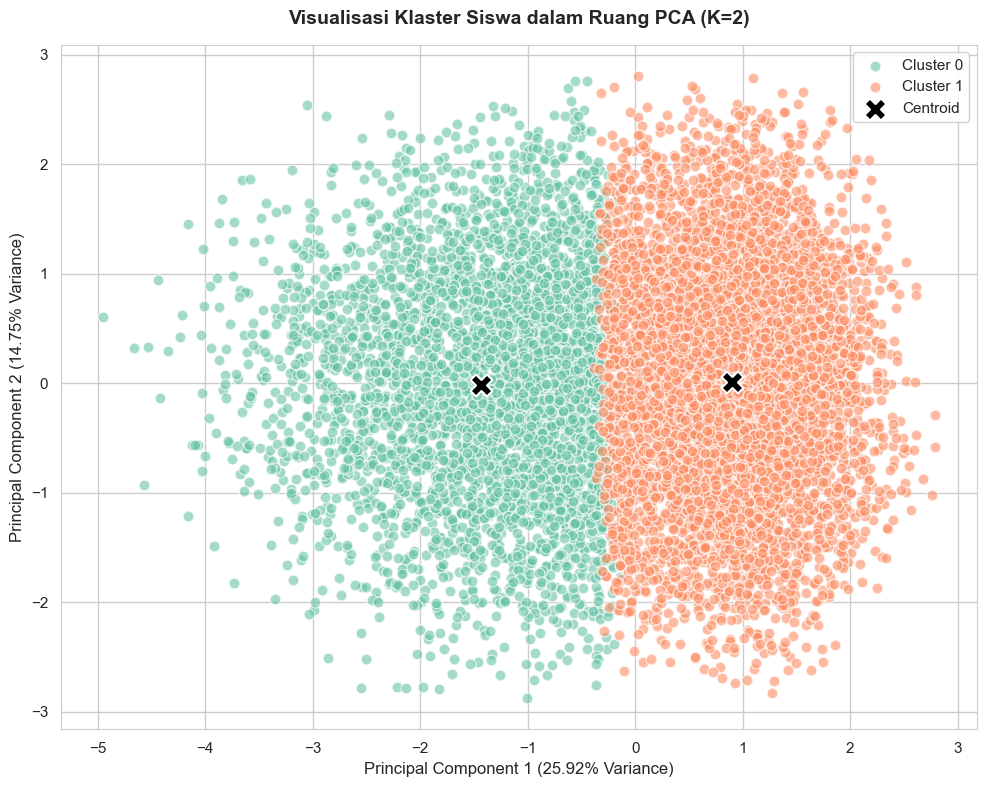

Total varian yang dijelaskan oleh 2 PC utama: 40.67%


In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

centroids_scaled = kmeans_model.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = final_labels

# Visualisasi 
plt.figure(figsize=(10, 8))
colors = sns.color_palette('Set2', n_colors=optimal_k)

for cluster_id in range(optimal_k):
    cluster_data = pca_df[pca_df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], 
                label=f'Cluster {cluster_id}', 
                alpha=0.6, edgecolors='w', s=60, color=colors[cluster_id])

# Plot Centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='black', marker='X', s=250, label='Centroid', edgecolor='white', linewidth=1.5)

plt.title(f'Visualisasi Klaster Siswa dalam Ruang PCA (K={optimal_k})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.savefig('cluster_visualization_pca.png', dpi=300)
plt.show()

print("Total varian yang dijelaskan oleh 2 PC utama:", f"{sum(pca.explained_variance_ratio_)*100:.2f}%")

## 8. Interpretasi dan Profil Setiap Klaster

=== RATA-RATA NILAI FITUR ASLI PER KLASTER ===


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
cluster,,,,,,,
0,3.705364,65.786732,6.242032,6.557139,7.266909,58.681524,70.781565
1,7.425012,72.459697,6.659665,5.751832,11.698583,68.825598,96.709984



=== TABEL KONTINGENSI PLACEMENT STATUS PER KLASTER ===


placement_status,Not Placed,Placed
cluster,,
0,1644,2215
1,0,6141


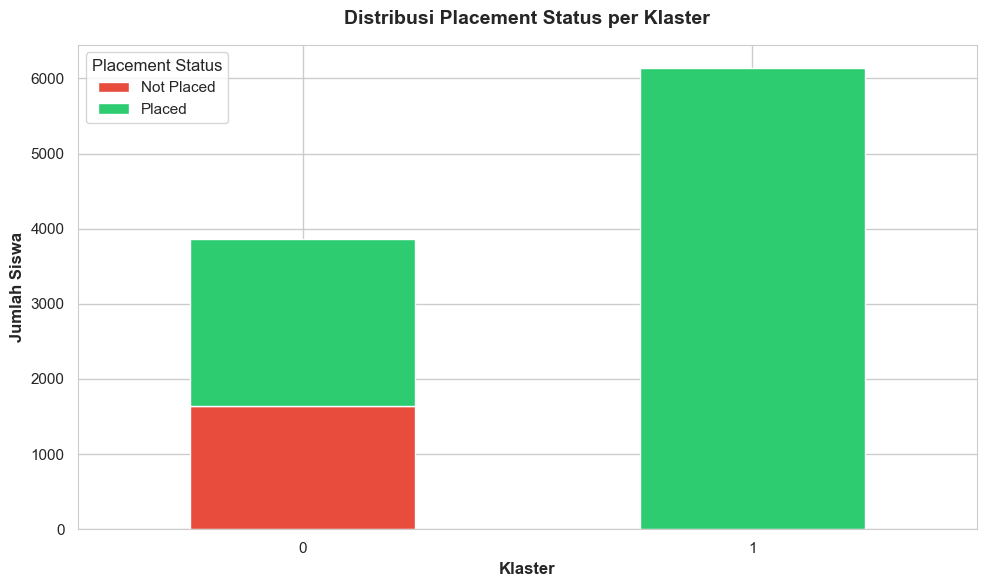

In [10]:
# Tambahkan kolom cluster ke DataFrame asli
df['cluster'] = final_labels

# 1. Hitung rata-rata nilai fitur asli per klaster
cluster_profile = df.groupby('cluster')[features_to_use].mean()
print("=== RATA-RATA NILAI FITUR ASLI PER KLASTER ===")
display(cluster_profile)

# 2. Analisis distribusi placement_status per klaster
contingency_table = pd.crosstab(df['cluster'], df['placement_status'])
print("\n=== TABEL KONTINGENSI PLACEMENT STATUS PER KLASTER ===")
display(contingency_table)

# Plot Bar Chart stacked untuk placement_status per klaster
plt.figure(figsize=(10, 6))
contingency_table.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'], ax=plt.gca())
plt.title('Distribusi Placement Status per Klaster', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Klaster', fontweight='bold')
plt.ylabel('Jumlah Siswa', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Placement Status', frameon=True)
plt.tight_layout()
plt.savefig('placement_status_distribution.png', dpi=300)
plt.show()

### Pembuatan Profil Karakteristik Klaster
Berdasarkan nilai rata-rata di atas, kita dapat menyimpulkan profil masing-masing klaster:

In [11]:
# Print ringkasan profil karakteristik klaster secara terperinci
for cluster_id in range(optimal_k):
    profile = cluster_profile.loc[cluster_id]
    placement_dist = contingency_table.loc[cluster_id]
    total_placed = placement_dist.get('Placed', 0)
    total_not_placed = placement_dist.get('Not Placed', 0)
    total_students = total_placed + total_not_placed
    pct_placed = (total_placed / total_students) * 100 if total_students > 0 else 0
    
    print(f"\n========================================")
    print(f"KLASTER {cluster_id} - Karakteristik Siswa:")
    print(f"========================================")
    print(f"- Rata-rata Jam Belajar         : {profile['study_hours']:.2f} jam/hari")
    print(f"- Rata-rata Kehadiran           : {profile['attendance']:.2f}%")
    print(f"- Rata-rata Jam Tidur           : {profile['sleep_hours']:.2f} jam/hari")
    print(f"- Rata-rata Penggunaan Internet : {profile['internet_usage']:.2f} jam/hari")
    print(f"- Rata-rata Tugas Selesai       : {profile['assignments_completed']:.2f} tugas")
    print(f"- Rata-rata Nilai Sebelumnya    : {profile['previous_score']:.2f}")
    print(f"- Rata-rata Nilai Ujian         : {profile['exam_score']:.2f}")
    print(f"- Persentase Kelulusan (Placed) : {pct_placed:.2f}% ({total_placed} dari {total_students} siswa)")


KLASTER 0 - Karakteristik Siswa:
- Rata-rata Jam Belajar         : 3.71 jam/hari
- Rata-rata Kehadiran           : 65.79%
- Rata-rata Jam Tidur           : 6.24 jam/hari
- Rata-rata Penggunaan Internet : 6.56 jam/hari
- Rata-rata Tugas Selesai       : 7.27 tugas
- Rata-rata Nilai Sebelumnya    : 58.68
- Rata-rata Nilai Ujian         : 70.78
- Persentase Kelulusan (Placed) : 57.40% (2215 dari 3859 siswa)

KLASTER 1 - Karakteristik Siswa:
- Rata-rata Jam Belajar         : 7.43 jam/hari
- Rata-rata Kehadiran           : 72.46%
- Rata-rata Jam Tidur           : 6.66 jam/hari
- Rata-rata Penggunaan Internet : 5.75 jam/hari
- Rata-rata Tugas Selesai       : 11.70 tugas
- Rata-rata Nilai Sebelumnya    : 68.83
- Rata-rata Nilai Ujian         : 96.71
- Persentase Kelulusan (Placed) : 100.00% (6141 dari 6141 siswa)


## 9. Simpan Hasil
Kita menambahkan kolom `cluster` ke dalam dataframe asli dan mengekspor hasilnya ke file CSV baru bernama `hasil_clustering.csv`.

In [12]:
output_file = 'hasil_clustering.csv'
df.to_csv(output_file, index=False)
print(f"File hasil clustering berhasil diekspor ke '{output_file}'")
print(f"Dimensi file ekspor: {df.shape[0]} baris, {df.shape[1]} kolom")

File hasil clustering berhasil diekspor ke 'hasil_clustering.csv'
Dimensi file ekspor: 10000 baris, 9 kolom
